In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.colors as mcolors
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)          
# Remove rows where 'fileID' is in removeFileID
df_info_filtered = df_info[~df_info['fileID'].isin(removeFileID)]

# # Assign the filtered DataFrame back to df_info
df_info = df_info_filtered

In [2]:


df_best = pd.read_csv('tables/best_groundingline_ms_method_per_model.csv')

df_m2100 = pd.read_csv('./tables/averegeshelfmelt_2100.csv')
df_m2200 = pd.read_csv('./tables/averegeshelfmelt_2200.csv')
df_m2300 = pd.read_csv('./tables/averegeshelfmelt_2300.csv')


df_bmb2100 = pd.read_csv('./tables/totalshelfmelt_2100.csv')
df_bmb2200 = pd.read_csv('./tables/totalshelfmelt_2200.csv')
df_bmb2300 = pd.read_csv('./tables/totalshelfmelt_2300.csv')
                         
df_dslr2100 = pd.read_csv('./tables/dslc_anom_2100.csv')
df_dslr2200 = pd.read_csv('./tables/dslc_anom_2200.csv')
df_dslr2300 = pd.read_csv('./tables/dslc_anom_2300.csv')

df_tf2100 = pd.read_csv('./tables/thermalforcing_2100.csv')
df_tf2200 = pd.read_csv('./tables/thermalforcing_2200.csv')
df_tf2300 = pd.read_csv('./tables/thermalforcing_2300.csv')

df_iareafl2100 = pd.read_csv('./tables/iareafl_2100.csv')
df_iareafl2200 = pd.read_csv('./tables/iareafl_2200.csv')
df_iareafl2300 = pd.read_csv('./tables/iareafl_2300.csv')

df_iareafl2100_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2100.csv')
df_iareafl2200_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2300.csv')
df_iareafl2300_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2300.csv')


df_iareagr2100_change = pd.read_csv('./tables/pchange_iareagr_2100.csv')
df_iareagr2200_change = pd.read_csv('./tables/pchange_iareagr_2200.csv')
df_iareagr2300_change = pd.read_csv('./tables/pchange_iareagr_2300.csv')

df_cumBMB2100 = pd.read_csv('./tables/cumulative_groundingline_melt_2100.csv')
df_cumBMB2200= pd.read_csv('./tables/cumulative_groundingline_melt_2200.csv')
df_cumBMB2300 = pd.read_csv('./tables/cumulative_groundingline_melt_2300.csv')

dfds = [
   df_dslr2100,
   df_dslr2200,
   df_dslr2300,
df_iareafl2100, 
df_iareafl2200 ,
df_iareafl2300 ,
df_iareafl2100_change ,
df_iareafl2200_change,
df_iareafl2300_change,
df_iareagr2100_change ,
df_iareagr2200_change,
df_iareagr2300_change,
        df_cumBMB2100,
    df_cumBMB2200 ,
    df_cumBMB2300 


]

for df_ms in dfds:
    df_ms['WestAntarctica'] = df_ms['region_1']
    df_ms['EastAntarctica'] = df_ms['region_2']
    df_ms['Peninsula'] = df_ms['region_3']
    
regions = ['AIS',
 'WestAntarctica',
 'EastAntarctica',
 'Peninsula',
           'Amundsen',
 'Ross',
 'FilchnerRonne']
regions_keys ={}
regions_keys['AIS'] = ['']
regions_keys['WestAntarctica']=['_region_1']
regions_keys['EastAntarctica']=['_region_2']
regions_keys['Peninsula']=['_region_3']
regions_keys['Amundsen']=['_sector_4']
regions_keys['Ross']=['_sector_2','_sector_6',]
regions_keys['FilchnerRonne']= ['_sector_5','_sector_11']
df_best['melt_sensetivity_FilchnerRonne']=df_best['melt_sensetivity_Filchner_Ronne']
df_best['melt_sensetivity_intercept_FilchnerRonne']=df_best['melt_sensetivity_intercept_Filchner_Ronne']


Models = df_best.Model.values

In [3]:
dfs = [
    df_iareafl2100_change,
   df_iareafl2200_change,
   df_iareafl2300_change]
regions_extra=[ 'Amundsen',
 'Ross',
 'FilchnerRonne']
for df in dfs:
    for key in regions_extra:
        y = 0
        for i,sectors in enumerate(regions_keys[key]):
        
            y =y + df[sectors[1:]]
        df[key]=y/(i+1)
    

In [4]:
dfs = [
    df_dslr2100,
   df_dslr2200,
   df_dslr2300]
regions_extra=[ 'Amundsen',
 'Ross',
 'FilchnerRonne']
for df in dfs:
    for key in regions_extra:
        y = 0
        for sectors in regions_keys[key]:
        
            y =y + df[sectors[1:]]
        df[key]=y

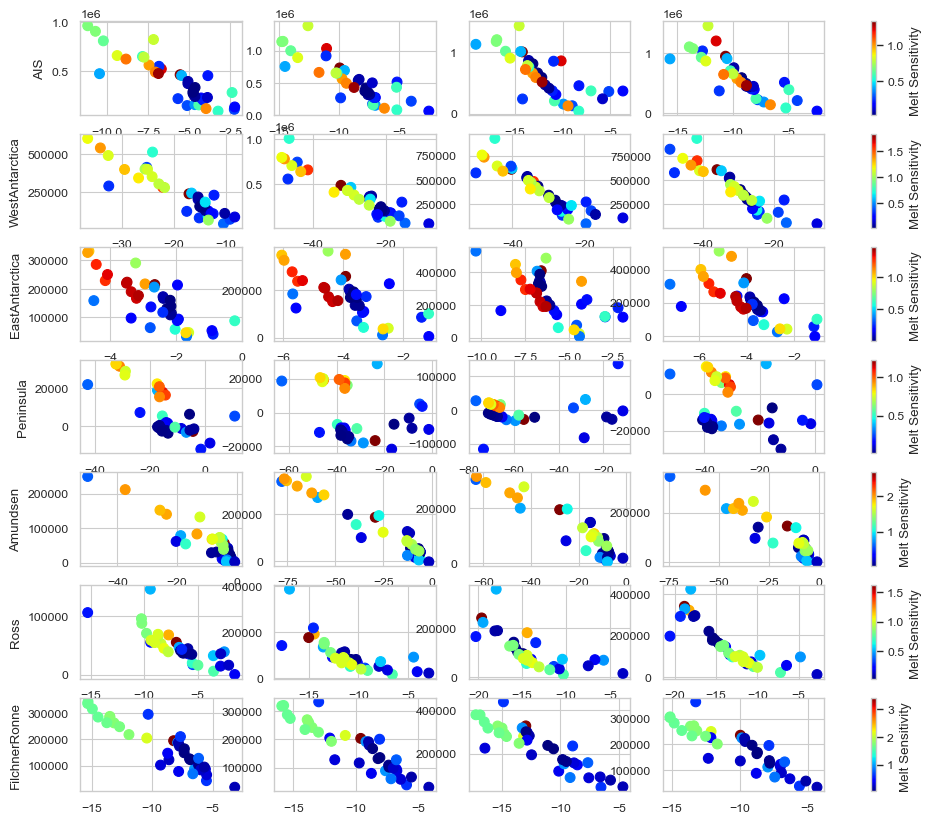

In [5]:
f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
dachange['Filchner_Ronne']= dachange['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_best[f'melt_sensetivity_{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region], dslr_exp[region], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'Melt Sensitivity ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

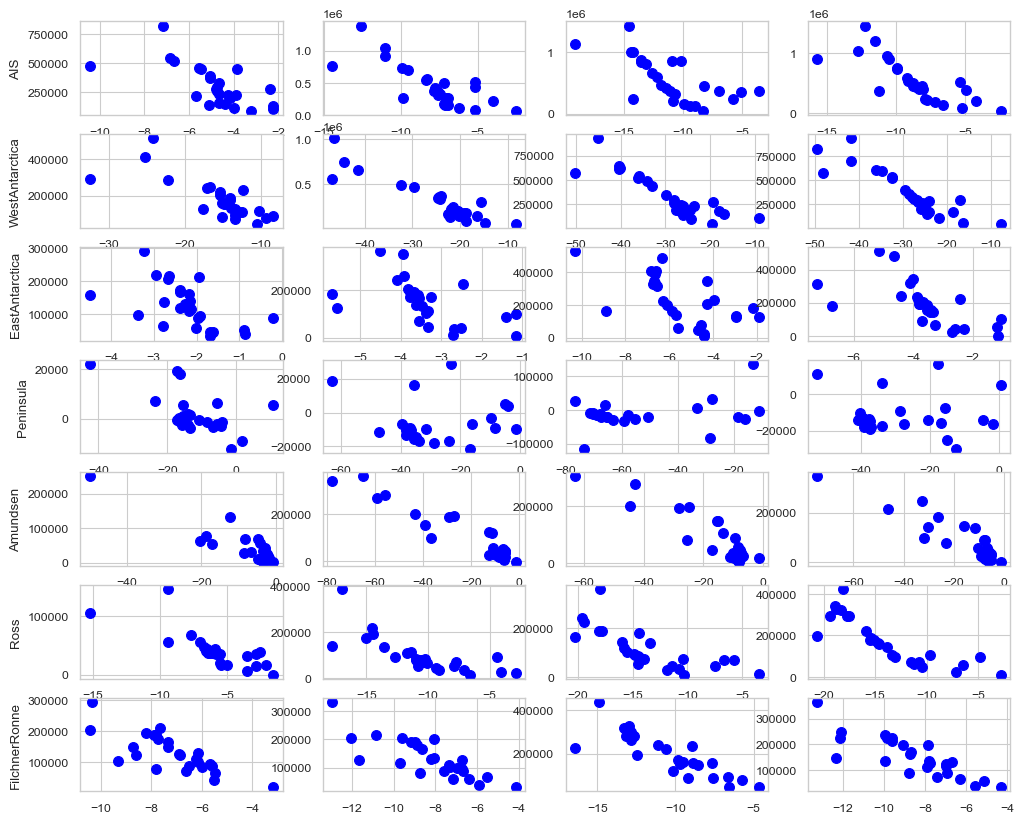

In [6]:
f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_best[f'melt_sensetivity_{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c='blue', s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
#     cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
#     cbar.set_label(f'Melt Sensitivity ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

### no VUW PISM

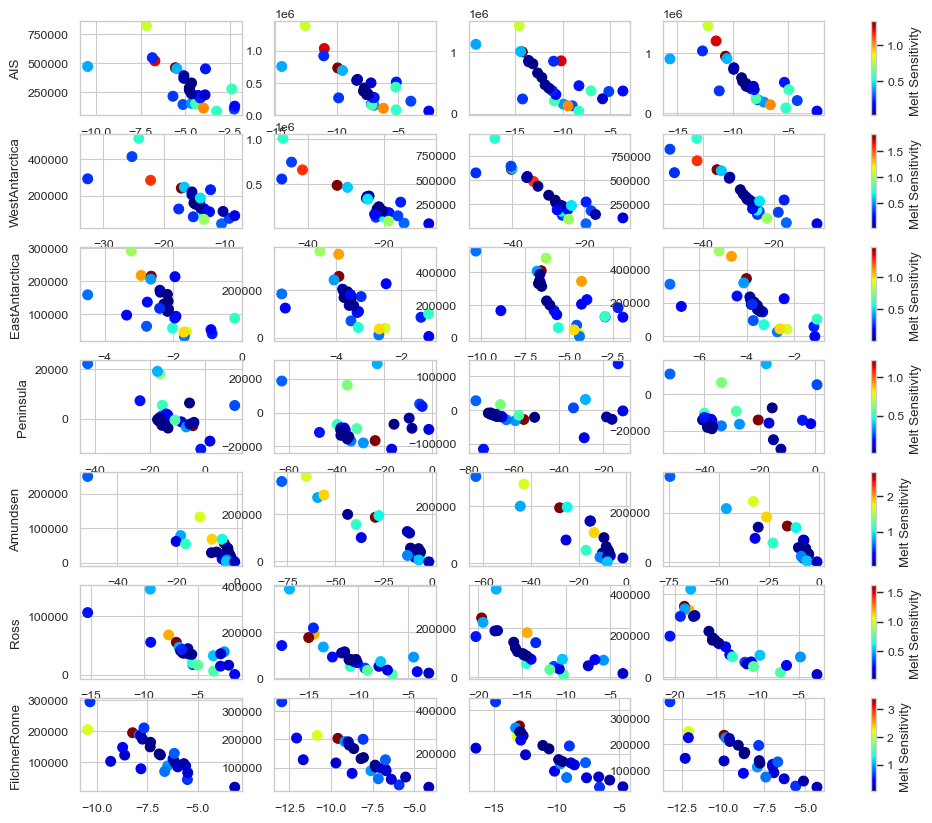

In [7]:
f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
dachange['Filchner_Ronne']= dachange['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_best[f'melt_sensetivity_{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'Melt Sensitivity ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

In [8]:
df_iareafl2300_change_mean = df_iareafl2300_change[df_iareafl2300_change.Experiment == 'expAE02']

for i,Model in enumerate(df_iareafl2300_change_mean.Model):
    dm =df_iareafl2300_change[df_iareafl2300_change.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
        df_iareafl2300_change_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

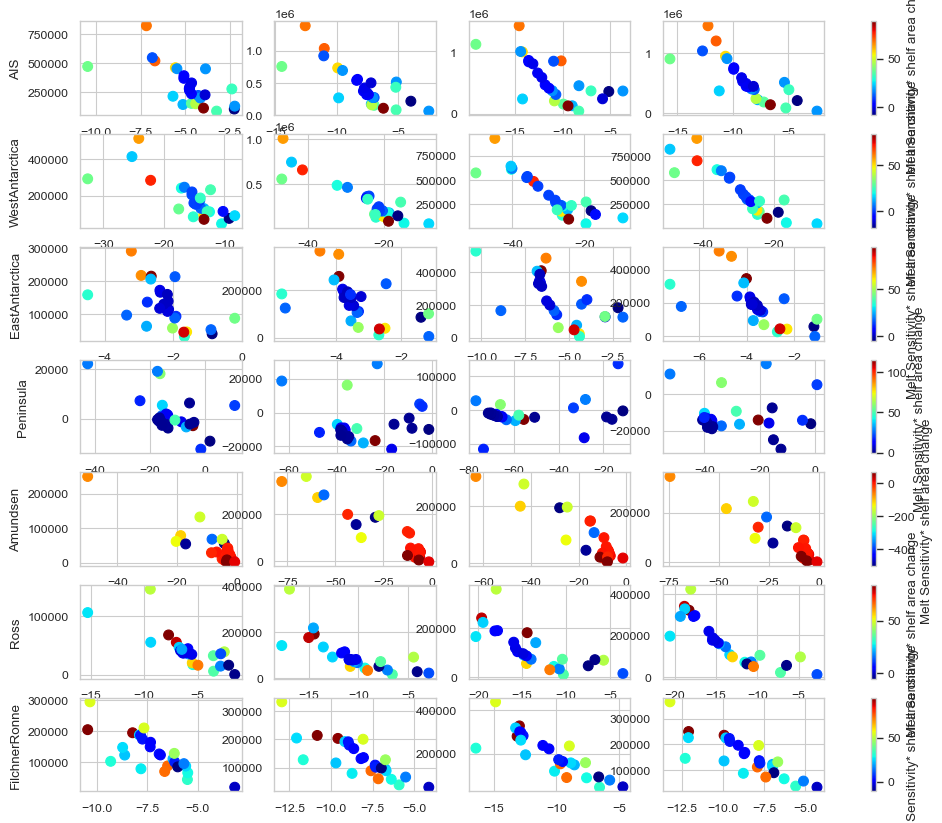

In [9]:
f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_best[f'melt_sensetivity_{region}'][:-10]*-1*df_iareafl2300_change_mean[f'{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'Melt Sensitivity* shelf area change ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

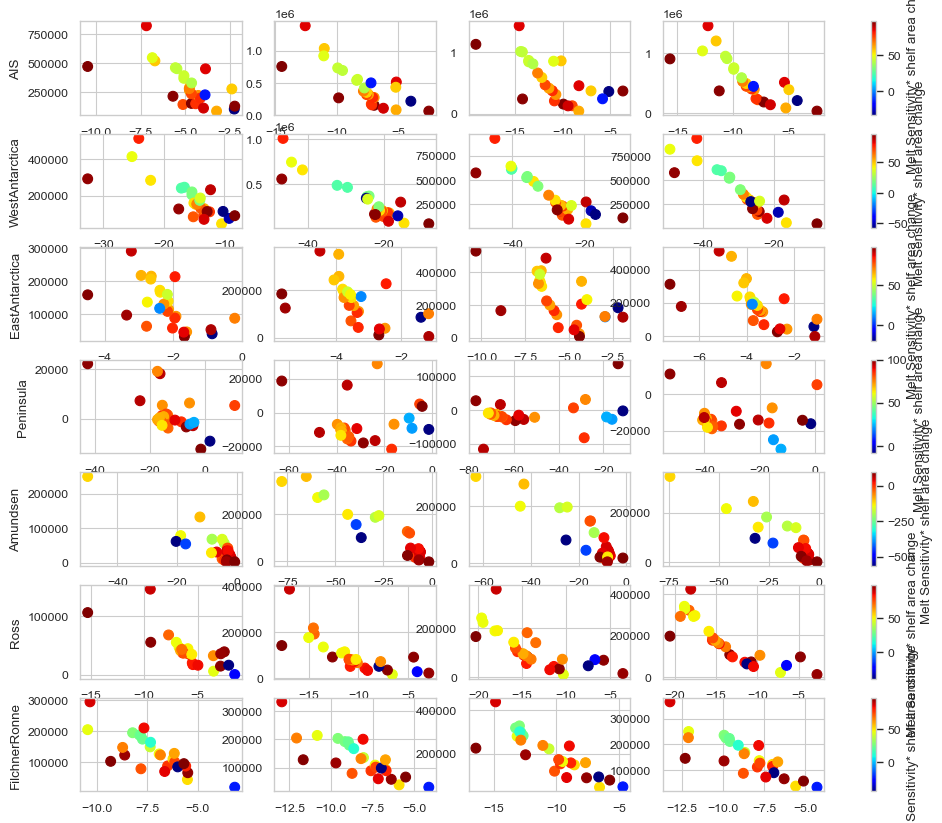

In [10]:
f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms =-1*df_iareafl2300_change_mean[f'{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'Melt Sensitivity* shelf area change ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    


### Does cumulative BMB play a role? -- YES but there are some exeptions!


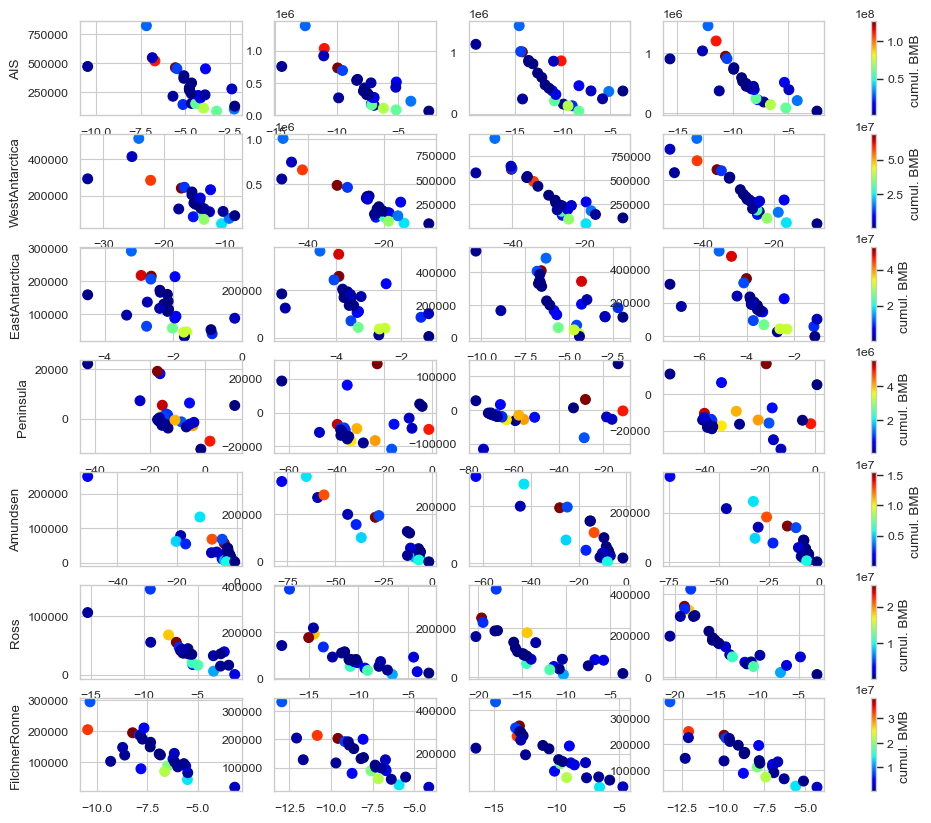

In [11]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

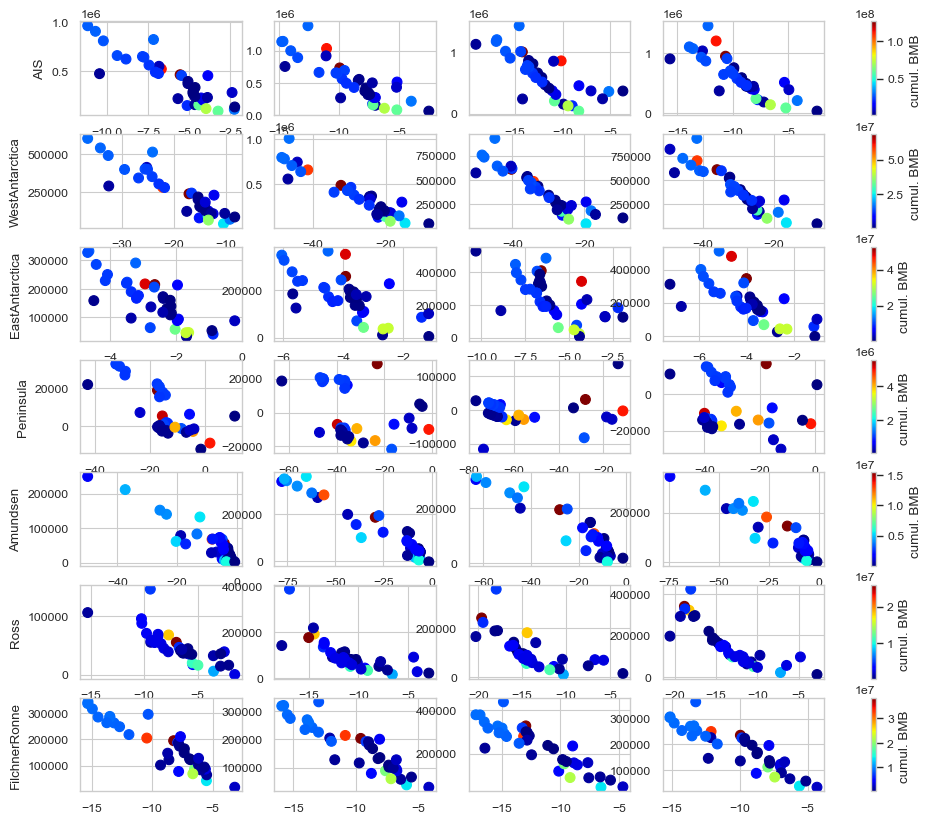

In [12]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region], dslr_exp[region], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

## different SLR over cumulative BMB

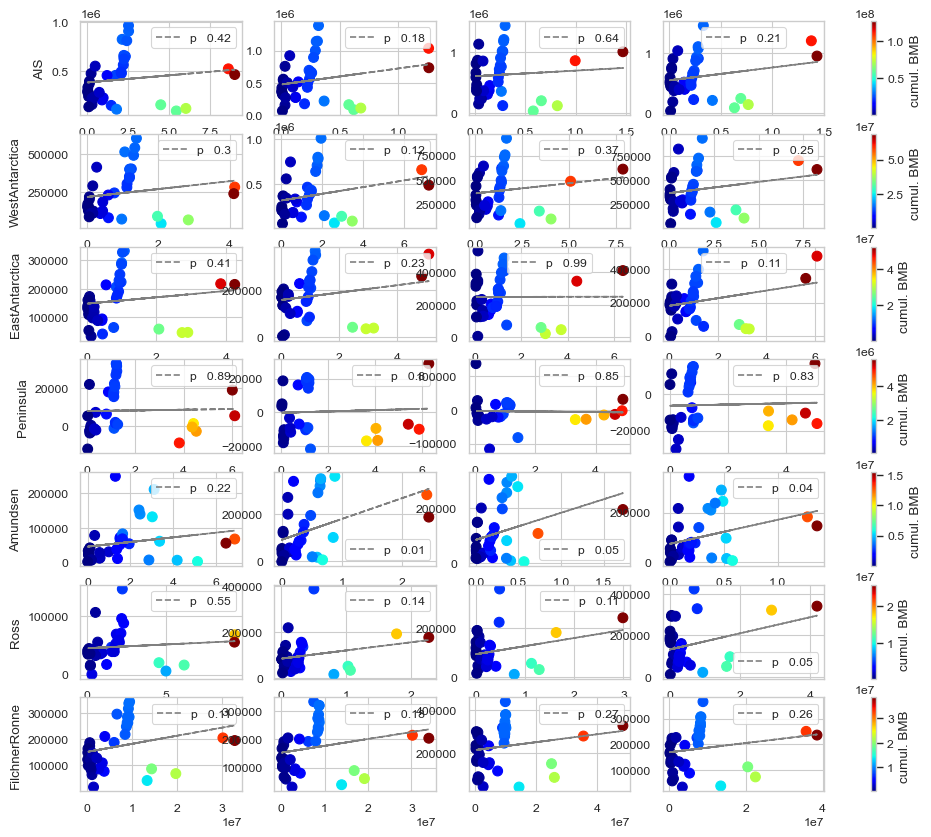

In [51]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region], dslr_exp[region], c=colors, s=50)
        slope, intercept, r, p, se = linregress(dachange_exp[region], dslr_exp[region])
        y= slope *dachange_exp[region] +intercept
        
        ax.plot(dachange_exp[region],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

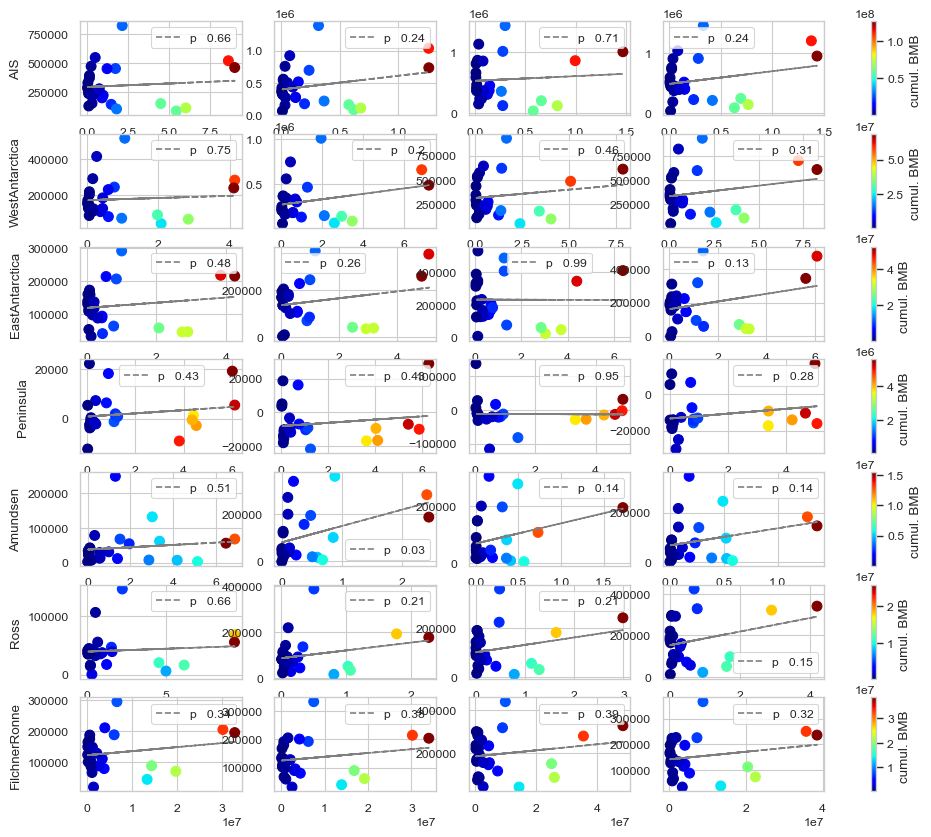

In [52]:
## different SLR over cumulative BMB = no vuw pism

df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        slope, intercept, r, p, se = linregress(dachange_exp[region][:-10], dslr_exp[region][:-10])
        y= slope *dachange_exp[region][:-10] +intercept
        
        ax.plot(dachange_exp[region][:-10],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
        
      
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

In [14]:
params_unique=df_info['Melt parameterisation'].unique()
df_info_exp= df_info[df_info.Experiment == 'expAE02']
unique_scatter = ['^','v','*','s','P','p']
dic_params_scatter = {}
marker_model = []
for i,param in enumerate(params_unique):
    dic_params_scatter[param]=unique_scatter[i]
for key in df_info_exp['Melt parameterisation']:
    marker_model.append( dic_params_scatter[key])
# for i,Model in enumerate( df_cumBMB2300_mean.Model):
# marker_model

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_11971/3736134485.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(xi, dslr_exp[region][k], c=colors[k], marker = marker_model[k],s=50)


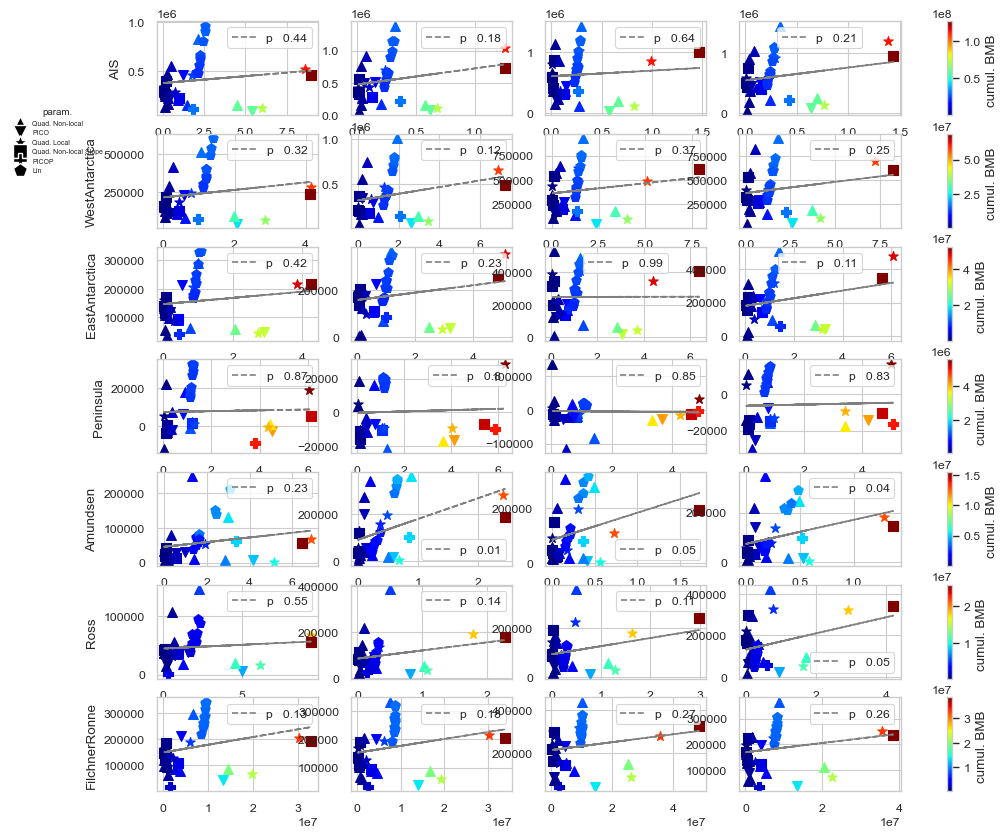

In [15]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_params_scatter.items()]

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']


df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        mvuw = dachange_exp.Model != 'VUW_PISM1_s1'
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        for k,xi in enumerate(dachange_exp[region].values):
        
        # Scatter plot with colors based on melt_sensetivity
            if exp == 'expAE02' and dachange_exp.Model[k] == 'VUW_PISM1_s1':
                continue
            else:
                scatter = ax.scatter(xi, dslr_exp[region][k], c=colors[k], marker = marker_model[k],s=50)
        if exp == 'expAE02':
            x =dachange_exp[region][mvuw]
            slope, intercept, r, p, se = linregress(x, dslr_exp[region][mvuw])
            y= slope *dachange_exp[region][mvuw] +intercept
        else:
            x = dachange_exp[region]
            slope, intercept, r, p, se = linregress(x, dslr_exp[region])
            y= slope *dachange_exp[region] +intercept
        
        ax.plot(x,y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=5, title_fontsize=7,frameon=False)
    #     ax[i].plot(Models.index,y)  
    

In [ ]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region], dslr_exp[region], c=colors, s=50)
        slope, intercept, r, p, se = linregress(dachange_exp[region], dslr_exp[region])
        y= slope *dachange_exp[region] +intercept
        
        ax.plot(dachange_exp[region],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

## different grounded area over cumulative BMB

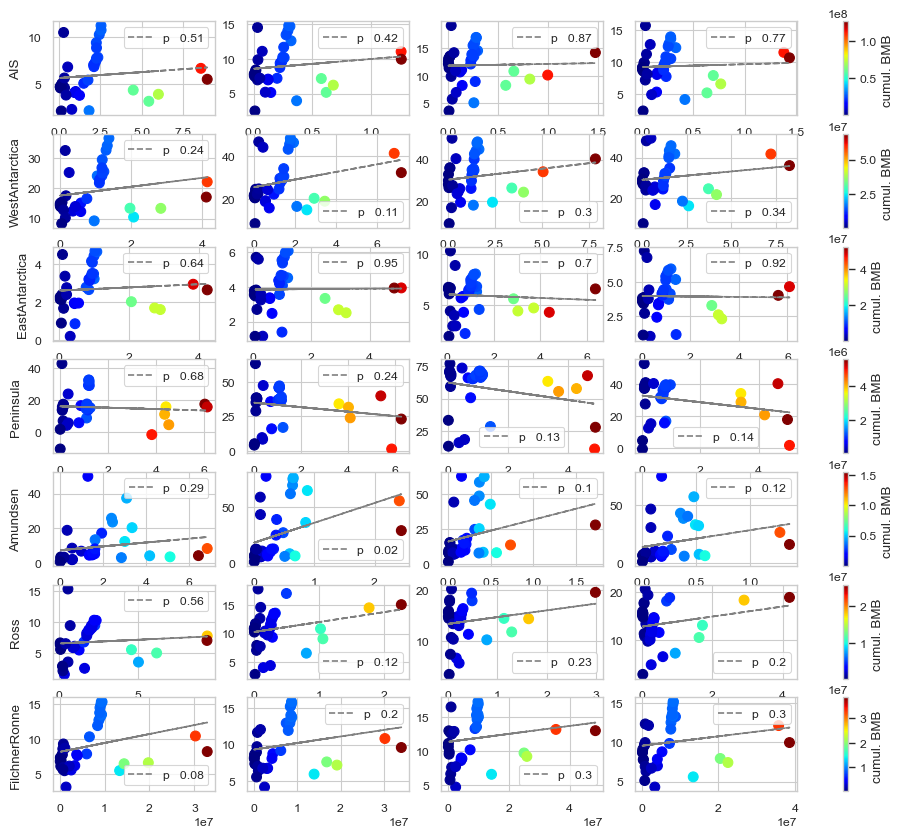

In [13]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_iareagr2300_change
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region], -1*dslr_exp[region], c=colors, s=50)
        slope, intercept, r, p, se = linregress(dachange_exp[region], -1*dslr_exp[region])
        y= slope *dachange_exp[region] +intercept
        
        ax.plot(dachange_exp[region],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

### now view pism

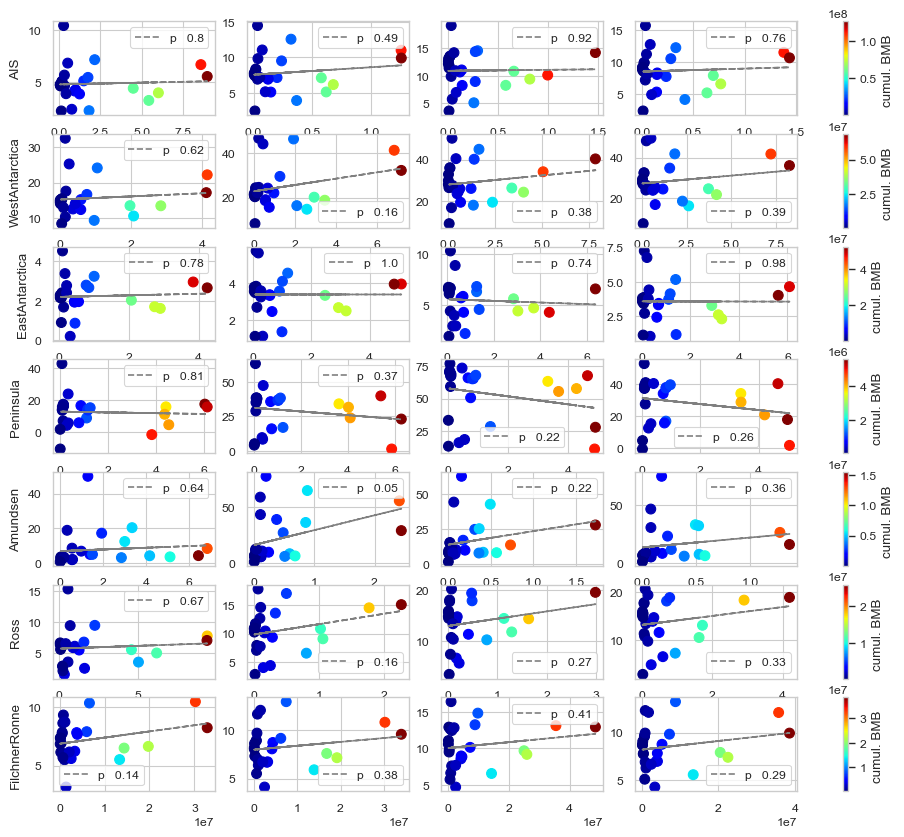

In [54]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_iareagr2300_change
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], -1*dslr_exp[region][:-10], c=colors, s=50)
        slope, intercept, r, p, se = linregress(dachange_exp[region][:-10], -1*dslr_exp[region][:-10])
        y= slope *dachange_exp[region][:-10] +intercept
        
        ax.plot(dachange_exp[region][:-10],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

###  again dyn slr gr. area retreat

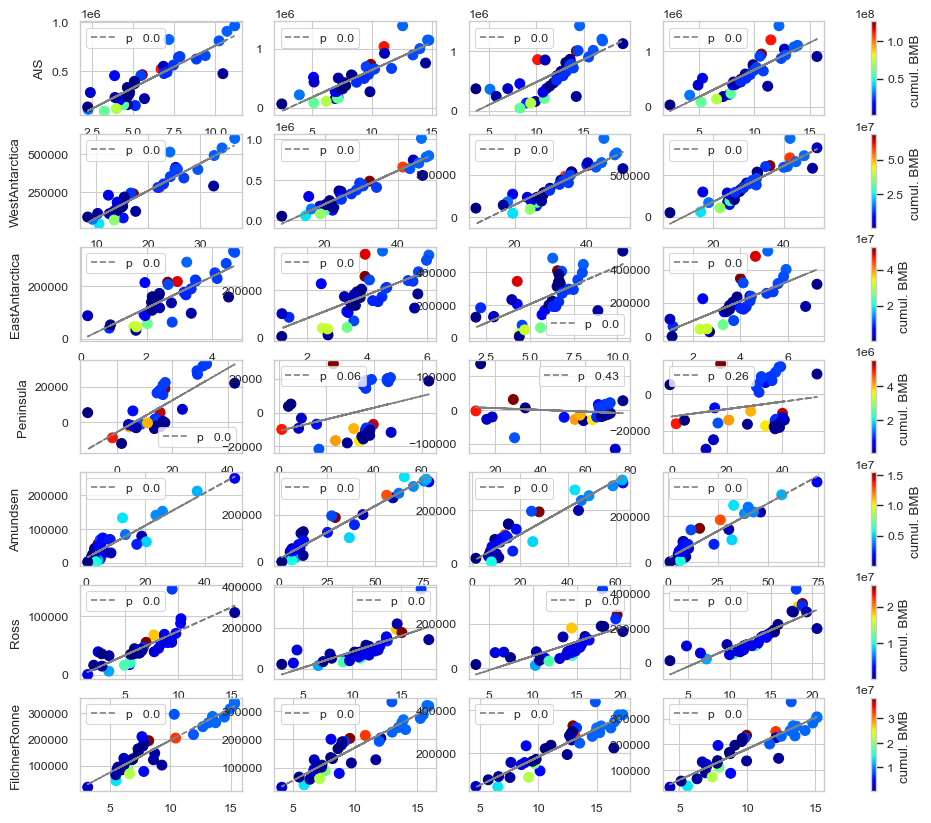

In [55]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
# df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(-1*dachange_exp[region],dslr_exp[region], c=colors, s=50)
        slope, intercept, r, p, se = linregress(-1*dachange_exp[region], dslr_exp[region])
        y= -1*slope*dachange_exp[region] +intercept
        
        ax.plot(-1*dachange_exp[region],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

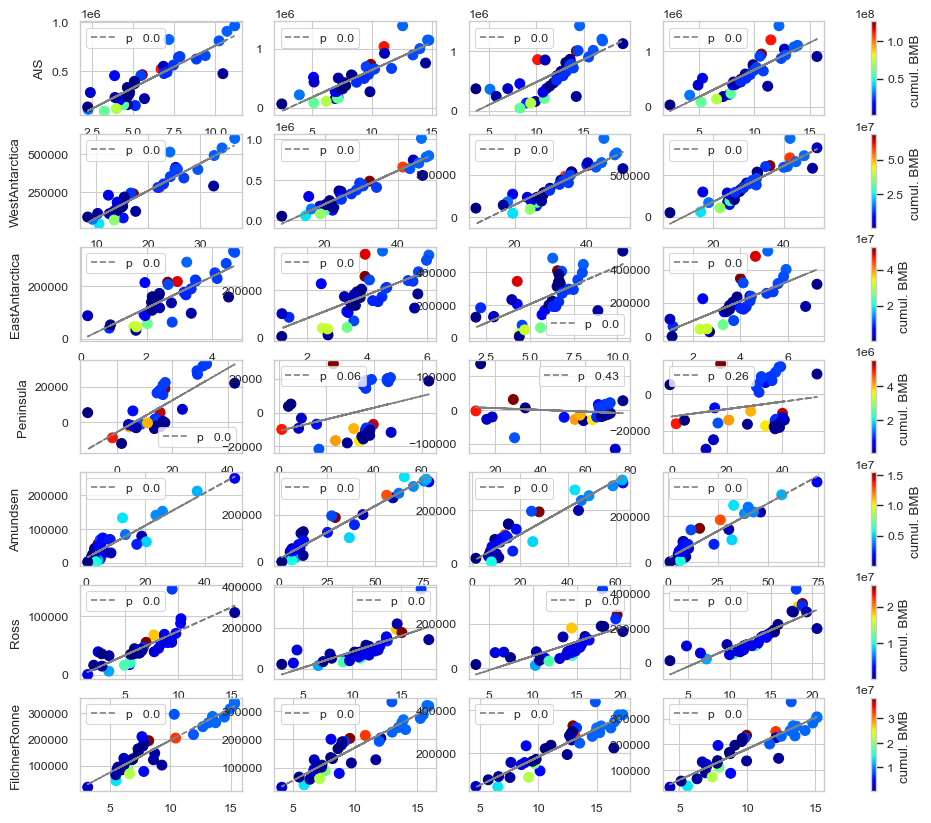

In [56]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(-1*dachange_exp[region],dslr_exp[region], c=colors, s=50)
        slope, intercept, r, p, se = linregress(-1*dachange_exp[region], dslr_exp[region])
        y= -1*slope*dachange_exp[region] +intercept
        
        ax.plot(-1*dachange_exp[region],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

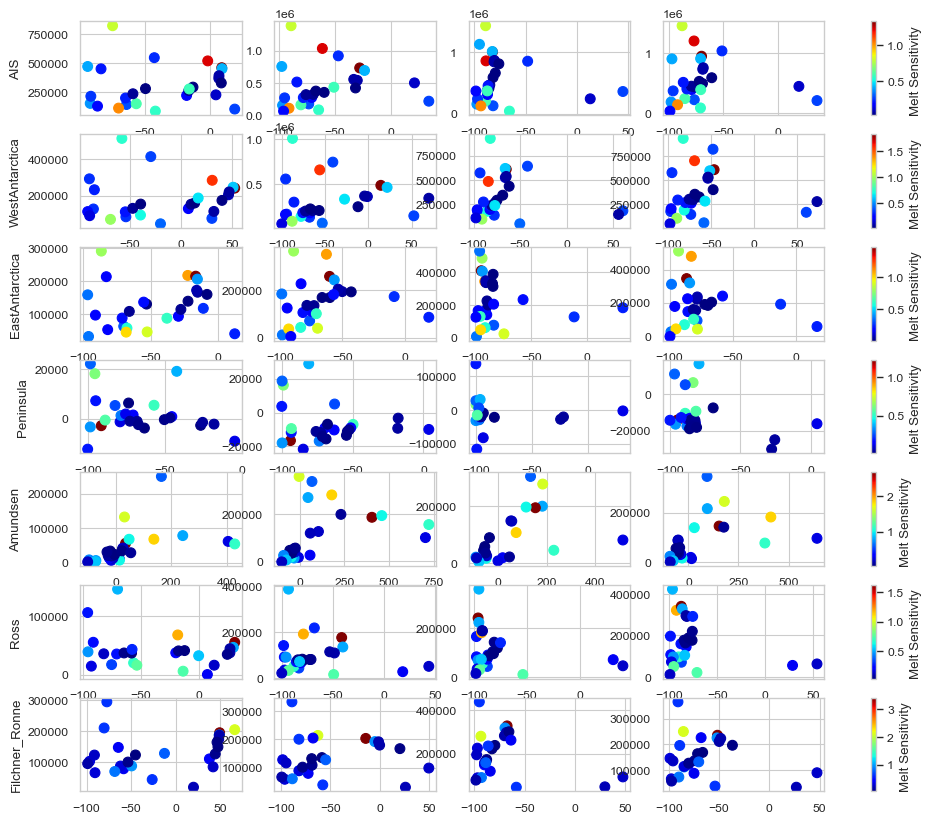

In [22]:
f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareafl2300_change
dachange['Filchner_Ronne']= dachange['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_best[f'melt_sensetivity_{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'Melt Sensitivity ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

In [23]:
df_iareafl2300_change

,Experiment,Model,Path,sector_1,sector_2,sector_3,sector_4,sector_5,sector_6,sector_7,...,region_1,region_2,region_3,FilchnerRonne,Ross,Amundsen,WestAntarctica,EastAntarctica,Peninsula,Filchner_Ronne
0,expAE02,DC_ISSM,/Volumes/CrucialX8/computing/data/antarctica/i...,-63.039815,-58.673155,-25.739586,13.460813,-55.428302,-92.183667,67.803127,...,-53.889662,-69.970185,-78.987229,-58.397114,-75.428411,13.460813,-53.889662,-69.970185,-78.987229,-58.397114
1,expAE02,IGE_ElmerIce,/Volumes/CrucialX8/computing/data/antarctica/i...,-83.706391,-6.762636,-77.340060,-15.628329,-19.501901,-20.996265,74.066126,...,-20.102638,-52.600718,-91.207355,-26.208774,-13.879451,-15.628329,-20.102638,-52.600718,-91.207355,-26.208774
2,expAE02,ILTS_SICOPOLIS,/Volumes/CrucialX8/computing/data/antarctica/i...,-92.000800,-42.046958,-96.253568,32.083455,-75.354671,-98.519498,-30.013332,...,-57.800692,-86.566448,-95.322472,-77.205028,-70.283228,32.083455,-57.800692,-86.566448,-95.322472,-77.205028
3,expAE02,LSCE_GRISLI2,/Volumes/CrucialX8/computing/data/antarctica/i...,-93.728632,-83.119190,-94.932300,-70.651245,-86.080599,-99.316150,-75.973845,...,-85.586041,-96.039569,-98.323745,-90.516427,-91.217670,-70.651245,-85.586041,-96.039569,-98.323745,-90.516427
4,expAE02,LSCE_GRISLI,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.155456,-92.292815,-98.374438,241.192222,-95.873302,-99.777299,-83.802909,...,-89.504772,-96.687543,-98.241365,-96.612770,-96.035057,241.192222,-89.504772,-96.687543,-98.241365,-96.612770
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,expAE05,VUW_PISM2,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.767566,-68.146491,-79.063886,191.905940,-92.320800,-93.966073,28.157696,...,-68.995512,-68.872815,-73.440021,-87.384921,-81.056282,191.905940,-68.995512,-68.872815,-73.440021,-87.384921
140,expAE05,VUW_PISM2_s1,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.766332,-67.166889,-82.010758,125.525439,-92.380697,-94.078696,5.346504,...,-71.583080,-66.375184,-75.565463,-86.355840,-80.622792,125.525439,-71.583080,-66.375184,-75.565463,-86.355840
141,expAE05,VUW_PISM2_s2,/Volumes/CrucialX8/computing/data/antarctica/i...,-96.981162,-75.486815,-70.431638,126.757336,-90.919381,-94.478965,54.344982,...,-73.680401,-70.460045,-77.843112,-85.439386,-84.982890,126.757336,-73.680401,-70.460045,-77.843112,-85.439386
142,expAE05,VUW_PISM2_s3,/Volumes/CrucialX8/computing/data/antarctica/i...,-99.304646,-75.496024,-69.032544,-32.931110,-91.281164,-93.890715,8.180991,...,-80.900341,-70.679981,-78.765953,-84.722916,-84.693369,-32.931110,-80.900341,-70.679981,-78.765953,-84.722916


In [16]:
df_best

,Unnamed: 0,Model,mean-error,method,parameterization,melt_sensetivity_AIS,melt_sensetivity_intercept_AIS,melt_sensetivity_Amundsen,melt_sensetivity_intercept_Amundsen,melt_sensetivity_Ross,...,melt_sensetivity_Filchner_Ronne,melt_sensetivity_intercept_Filchner_Ronne,melt_sensetivity_WestAntarctica,melt_sensetivity_intercept_WestAntarctica,melt_sensetivity_EastAntarctica,melt_sensetivity_intercept_EastAntarctica,melt_sensetivity_Peninsula,melt_sensetivity_intercept_Peninsula,melt_sensetivity_FilchnerRonne,melt_sensetivity_intercept_FilchnerRonne
0,0,DC_ISSM,1.853524,df_maxbmb,Quad. Non-local,0.279796,0.060907,0.288132,1.054022,0.334822,...,0.367383,-0.038477,0.329251,0.011838,0.318088,0.024222,0.117871,0.117242,0.367383,-0.038477
1,1,IGE_ElmerIce,5.124112,df_maxbmb,PICO,0.555169,0.241474,0.250569,2.081113,0.737996,...,0.618789,-0.364427,0.422812,0.355278,0.896206,-0.030202,1.226679,-0.583978,0.618789,-0.364427
2,2,ILTS_SICOPOLIS,2.712475,df_maxbmb_2100,Quad. Non-local,0.798253,-0.363560,1.640232,-0.306777,0.516820,...,0.618669,-0.318878,0.741188,-0.280469,0.798360,-0.332787,0.621974,-0.449947,0.618669,-0.318878
3,3,LSCE_GRISLI2,3.440019,df_maxbmb_2100,Quad. Non-local,0.372984,-0.191822,0.756686,-0.098807,0.252829,...,0.296752,-0.159205,0.323395,-0.138282,0.362562,-0.147512,0.341632,-0.308723,0.296752,-0.159205
4,4,LSCE_GRISLI,3.508889,df_maxbmb_2100,Quad. Non-local,0.399157,-0.222417,0.790564,-0.154721,0.265364,...,0.310195,-0.167951,0.326860,-0.154177,0.360366,-0.151074,0.276966,-0.230111,0.310195,-0.167951
5,5,NCAR_CISM1,1.894577,df_maxbmb_2k,Quad. Non-local,0.598076,-0.231648,0.998707,-1.206391,0.682192,...,0.950360,-0.569910,0.691433,-0.301333,0.584167,-0.236883,0.305044,0.091967,0.950360,-0.569910
6,6,NCAR_CISM2,1.767217,df_maxbmb,Quad. Local,1.229462,-0.404258,1.850484,-1.657088,1.184411,...,2.105905,-0.922383,1.568962,-0.728606,1.091191,-0.159608,0.372645,0.124263,2.105905,-0.922383
7,7,NORCE_CISM2-MAR364-ERA-t1,3.636297,df_maxbmb,Quad. Non-local Slope,1.334803,-0.553924,2.690585,-3.165239,1.619932,...,3.417316,-2.342774,1.827122,-1.037523,1.468488,-0.507378,0.518418,-0.216420,3.417316,-2.342774
8,8,NORCE_CISM3-MAR364-ERA-t1-local,1.924737,df_maxbmb_2k,Quad. Local,0.184921,-0.057338,0.191351,0.007064,0.239244,...,0.402137,-0.233792,0.238463,-0.085903,0.176983,-0.047710,0.144019,-0.055561,0.402137,-0.233792
9,9,NORCE_CISM3-MAR364-ERA-t1-nonlocal,1.999465,df_maxbmb,Quad. Non-local,0.219580,-0.109879,0.296078,-0.202942,0.254642,...,0.307179,-0.142307,0.274420,-0.165842,0.209810,-0.076827,0.132571,-0.040842,0.307179,-0.142307
